# 2022 国赛 C 题｜第 2 课：列联表与卡方检验

本课只解决问题 1 的第一小部分：

> 表面风化是否与玻璃类型、纹饰、颜色有关？

核心思路：

1. 先看各组风化比例；
2. 再用卡方检验判断差异是否可能来自随机波动；
3. 检查卡方检验的适用条件；
4. 用 Cramér's V 衡量关系强弱。


## 0. 导入数据
把本 Notebook 与 `附件.xlsx` 放在同一文件夹。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

info = pd.read_excel(
    '附件.xlsx',
    sheet_name='表单1',
    dtype={'文物编号': str}
)
info['文物编号'] = info['文物编号'].str.zfill(2)

display(info.head())
print(info.shape)


,文物编号,纹饰,类型,颜色,表面风化
0,01,C,高钾,蓝绿,无风化
1,02,A,铅钡,浅蓝,风化
2,03,A,高钾,蓝绿,无风化
3,04,A,高钾,蓝绿,无风化
4,05,A,高钾,蓝绿,无风化


(58, 5)


## 1. 先看比例，不要一上来就看 p 值

列联表统计的是人数；行百分比回答的是“每一类中有多少比例发生了风化”。


In [2]:
def show_relation(df, variable):
    count_table = pd.crosstab(df[variable], df['表面风化'])
    rate_table = pd.crosstab(
        df[variable],
        df['表面风化'],
        normalize='index'
    )

    print(f'【{variable} × 表面风化：数量】')
    display(count_table)

    print(f'【{variable} × 表面风化：行百分比】')
    display((rate_table * 100).round(1).astype(str) + '%')

    return count_table, rate_table

type_count, type_rate = show_relation(info, '类型')


【类型 × 表面风化：数量】


表面风化,无风化,风化
类型,,
铅钡,12,28
高钾,12,6


【类型 × 表面风化：行百分比】


表面风化,无风化,风化
类型,,
铅钡,30.0%,70.0%
高钾,66.7%,33.3%


你应当看到：

- 高钾玻璃：18 件，其中 6 件风化，风化率约 33.3%；
- 铅钡玻璃：40 件，其中 28 件风化，风化率 70.0%。

肉眼看差别很大，但我们还要判断：这会不会只是抽样波动？


## 2. 卡方检验到底在问什么？

零假设：

> 玻璃类型与表面风化相互独立，没有关系。

若 p 值小于 0.05，我们通常拒绝零假设，认为二者存在统计关联。

注意：p 值不是“零假设正确的概率”，也不是关系强弱。


In [3]:
chi2, p, dof, expected = chi2_contingency(type_count)

print(f'卡方统计量 = {chi2:.4f}')
print(f'p 值 = {p:.4f}')
print(f'自由度 = {dof}')

expected_df = pd.DataFrame(
    expected,
    index=type_count.index,
    columns=type_count.columns
)
print('零假设成立时的期望频数：')
display(expected_df.round(2))


卡方统计量 = 5.4518
p 值 = 0.0195
自由度 = 1
零假设成立时的期望频数：


表面风化,无风化,风化
类型,,
铅钡,16.55,23.45
高钾,7.45,10.55


正确结果约为：

- χ² = 5.4518
- p = 0.0195

因为 `0.0195 < 0.05`，所以在 5% 显著性水平下，可以认为玻璃类型与表面风化存在统计关联。


## 3. p 值只说“有没有证据”，Cramér's V 说明“关系多强”


In [4]:
def cramers_v(count_table):
    chi2, _, _, _ = chi2_contingency(count_table)
    n = count_table.to_numpy().sum()
    rows, cols = count_table.shape
    return np.sqrt(chi2 / (n * min(rows - 1, cols - 1)))

v_type = cramers_v(type_count)
print(f"Cramér's V = {v_type:.4f}")


Cramér's V = 0.3066


这里 Cramér's V 约为 0.307，可描述为存在一定程度的关联。

不要机械套用“0.1 弱、0.3 中、0.5 强”。样本量、领域背景和表格维度都会影响解释。


## 4. 把过程封装成一个函数

这个函数同时输出：

- 数量和比例；
- 卡方统计量与 p 值；
- Cramér's V；
- 期望频数是否过小。


In [5]:
def categorical_relation_test(df, variable, target='表面风化'):
    temp = df[[variable, target]].dropna()

    count_table = pd.crosstab(temp[variable], temp[target])
    rate_table = pd.crosstab(
        temp[variable],
        temp[target],
        normalize='index'
    )

    chi2, p, dof, expected = chi2_contingency(count_table)
    expected_df = pd.DataFrame(
        expected,
        index=count_table.index,
        columns=count_table.columns
    )

    n = count_table.to_numpy().sum()
    rows, cols = count_table.shape
    v = np.sqrt(chi2 / (n * min(rows - 1, cols - 1)))

    small_expected = int((expected < 5).sum())
    total_expected = expected.size

    print(f'变量：{variable}')
    print('\n数量：')
    display(count_table)

    print('行百分比：')
    display((rate_table * 100).round(1).astype(str) + '%')

    print(f'χ² = {chi2:.4f}')
    print(f'p = {p:.4f}')
    print(f"自由度 = {dof}")
    print(f"Cramér's V = {v:.4f}")
    print(f'期望频数小于 5：{small_expected}/{total_expected}')

    if small_expected > 0:
        print('警告：部分期望频数过小，普通卡方近似可能不可靠。')

    return {
        'count': count_table,
        'rate': rate_table,
        'expected': expected_df,
        'chi2': chi2,
        'p': p,
        'dof': dof,
        'cramers_v': v
    }


## 5. 分析纹饰


In [6]:
pattern_result = categorical_relation_test(info, '纹饰')


变量：纹饰

数量：


表面风化,无风化,风化
纹饰,,
A,11,11
B,0,6
C,13,17


行百分比：


表面风化,无风化,风化
纹饰,,
A,50.0%,50.0%
B,0.0%,100.0%
C,43.3%,56.7%


χ² = 4.9565
p = 0.0839
自由度 = 2
Cramér's V = 0.2923
期望频数小于 5：2/6
警告：部分期望频数过小，普通卡方近似可能不可靠。


预期结果约为：

- A 纹饰风化率 50.0%；
- B 纹饰风化率 100.0%；
- C 纹饰风化率 56.7%；
- p ≈ 0.0839。

因为 p 大于 0.05，不能认为纹饰与风化存在显著关联。

但还有一个更重要的问题：B 类只有 6 件，导致部分期望频数小于 5，因此普通卡方检验的近似条件不理想。论文中应当注明这个限制，而不能只抄一句“p 大于 0.05”。


## 6. 分析颜色


In [7]:
color_result = categorical_relation_test(info, '颜色')


变量：颜色

数量：


表面风化,无风化,风化
颜色,,
浅绿,2,1
浅蓝,8,12
深绿,3,4
深蓝,2,0
紫,2,2
绿,1,0
蓝绿,6,9
黑,0,2


行百分比：


表面风化,无风化,风化
颜色,,
浅绿,66.7%,33.3%
浅蓝,40.0%,60.0%
深绿,42.9%,57.1%
深蓝,100.0%,0.0%
紫,50.0%,50.0%
绿,100.0%,0.0%
蓝绿,40.0%,60.0%
黑,0.0%,100.0%


χ² = 6.2871
p = 0.5066
自由度 = 7
Cramér's V = 0.3412
期望频数小于 5：12/16
警告：部分期望频数过小，普通卡方近似可能不可靠。


颜色有 8 个已知类别，而且许多颜色只有 1～4 件样本。你会发现大量期望频数小于 5。

因此：

- 可以展示各颜色的风化数量和比例；
- 不宜直接把普通卡方检验的 p 值当成可靠结论；
- 更稳妥的方法包括合并有考古意义的颜色类别、精确检验或置换检验；
- 不能为了让 p 值显著而随意合并颜色。


## 7. 绘图：画比例通常比画数量更容易比较


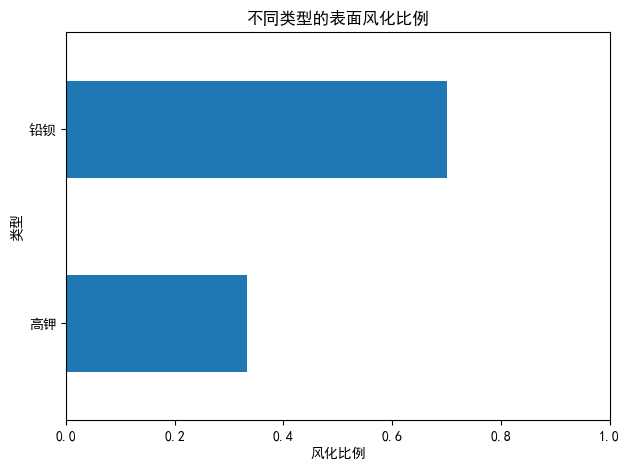

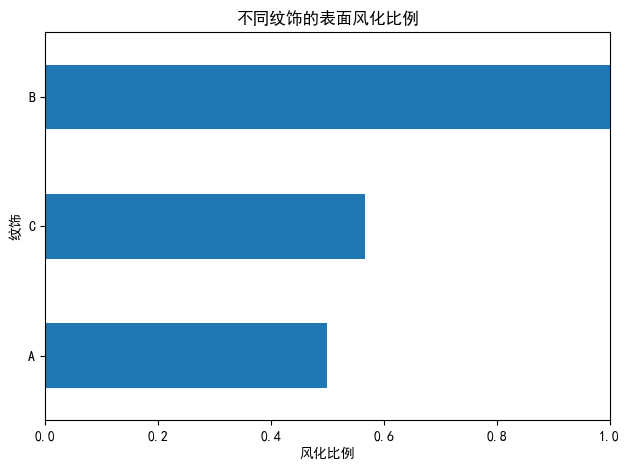

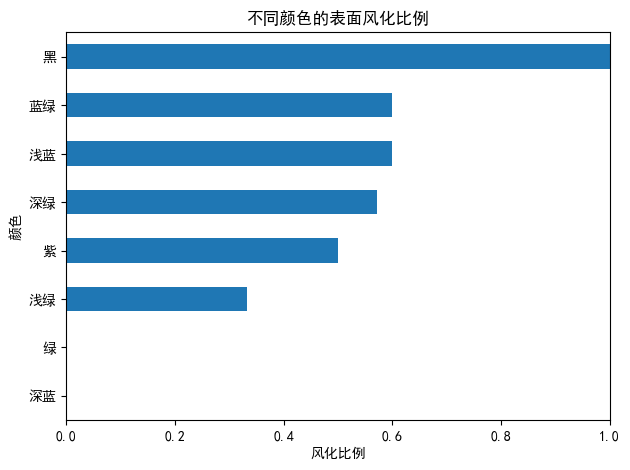

In [8]:
def plot_weathering_rate(df, variable):
    rate = pd.crosstab(
        df[variable],
        df['表面风化'],
        normalize='index'
    )

    if '风化' not in rate.columns:
        raise ValueError('数据中没有“风化”类别')

    rate['风化'].sort_values().plot(kind='barh')
    plt.xlabel('风化比例')
    plt.ylabel(variable)
    plt.title(f'不同{variable}的表面风化比例')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

plot_weathering_rate(info, '类型')
plot_weathering_rate(info, '纹饰')
plot_weathering_rate(info, '颜色')


## 8. 可以写进论文的第一版结论

基于 58 件玻璃文物的基本信息，采用列联表分析不同类别文物的表面风化比例，并利用 Pearson 卡方检验判断分类变量与表面风化之间的关联性。结果显示，高钾玻璃与铅钡玻璃的风化率分别约为 33.3% 和 70.0%，二者差异具有统计显著性（χ²≈5.452，p≈0.020），说明玻璃类型与表面风化存在一定关联。纹饰与表面风化的卡方检验结果未达到 5% 显著性水平（p≈0.084），且部分期望频数偏小，故尚无充分证据认定二者存在稳定关联。颜色变量的类别较多且部分颜色样本量很少，普通卡方检验的适用条件不足，因此仅作描述性分析，不对其关联性作强结论。


## 9. 你现在需要真正弄懂的三件事

1. `pd.crosstab` 只是计数，不是模型；
2. p 值小于 0.05 表示反对“相互独立”的证据较强；
3. 检验条件不满足时，即使代码能跑出 p 值，也不能盲信。

下一步将进入问题 1 的第二部分：比较高钾和铅钡玻璃在风化前后，各化学成分如何变化。
